# Ethiopia Financial Inclusion EDA, 2011-2024

Dedicated exploratory notebook for Ethiopia's 2011-2024 financial inclusion dynamics. It uses `data/processed/ethiopia_fi_enriched.csv`, regenerates it from `src/data_enrichment.py` if needed, writes supporting figures to `reports/figures`, and documents key insights with plots.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_enrichment import generate_enriched_dataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "ethiopia_fi_enriched.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    generate_enriched_dataset()

df = pd.read_csv(DATA_PATH, parse_dates=["observation_date"])
obs = df[df["record_type"] == "observation"].copy()
events = df[df["record_type"] == "event"].copy()
targets = df[df["record_type"] == "target"].copy()

print(f"Loaded {len(df)} enriched rows: {len(obs)} observations, {len(events)} events, {len(targets)} targets")

Loaded 57 enriched rows: 30 observations, 10 events, 3 targets


In [2]:
def series(code):
    return obs[obs["indicator_code"].eq(code)].sort_values("observation_date").copy()

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"saved: {path.relative_to(PROJECT_ROOT)}")

source_audit = df.groupby(["record_type", "confidence"], dropna=False).size().unstack(fill_value=0)
source_audit

confidence,high,large,medium,small
record_type,,,,
event,7,0,3,0
impact_link,0,1,7,6
observation,24,0,6,0
target,3,0,0,0


## Insight 1: Account ownership grew strongly from 2011 to 2021, then slowed sharply in 2021-2024.

The headline access series rises from 14% in 2011 to 49% in 2024. The fastest Findex interval is 2014-2017, while 2021-2024 adds only 3 percentage points despite major digital-finance launches. This points to a conversion problem: product availability and registrations are not automatically becoming Findex-counted active accounts.

saved: reports\figures\eda_account_ownership_event_overlay.png


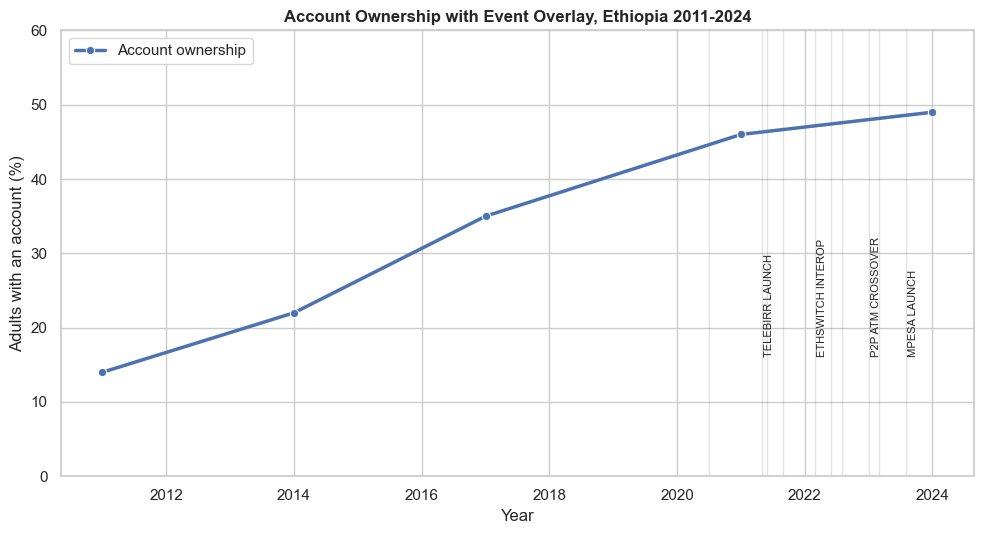

In [3]:
access = series("ACC_OWNERSHIP")
fig, ax = plt.subplots()
sns.lineplot(data=access, x="observation_year", y="value_numeric", marker="o", linewidth=2.5, ax=ax, label="Account ownership")
for _, row in events.iterrows():
    year = row["observation_date"].year + (row["observation_date"].dayofyear - 1) / 365.25
    if 2011 <= year <= 2024:
        ax.axvline(year, color="#777777", alpha=0.22, linewidth=1)
        if row["indicator_code"] in ["TELEBIRR_LAUNCH", "ETHSWITCH_INTEROP", "MPESA_LAUNCH", "P2P_ATM_CROSSOVER"]:
            ax.text(year + 0.03, 16, row["indicator_code"].replace("_", " "), rotation=90, va="bottom", fontsize=8)
ax.set_title("Account Ownership with Event Overlay, Ethiopia 2011-2024")
ax.set_xlabel("Year")
ax.set_ylabel("Adults with an account (%)")
ax.set_ylim(0, 60)
savefig("eda_account_ownership_event_overlay.png")
plt.show()

## Insight 2: The 2021-2024 slowdown is definitional, not evidence that digital finance stalled.

Telebirr registrations rose from 10 million in 2022 to 54 million in 2024, and M-Pesa reached 10 million registered users in 2024. Yet mobile-money account ownership in Findex is only 9.45% in 2024. Operator registrations are broad supply-side counts; Findex captures active adult ownership/use. The gap is the core analytical challenge.

saved: reports\figures\eda_mobile_money_active_vs_registered.png


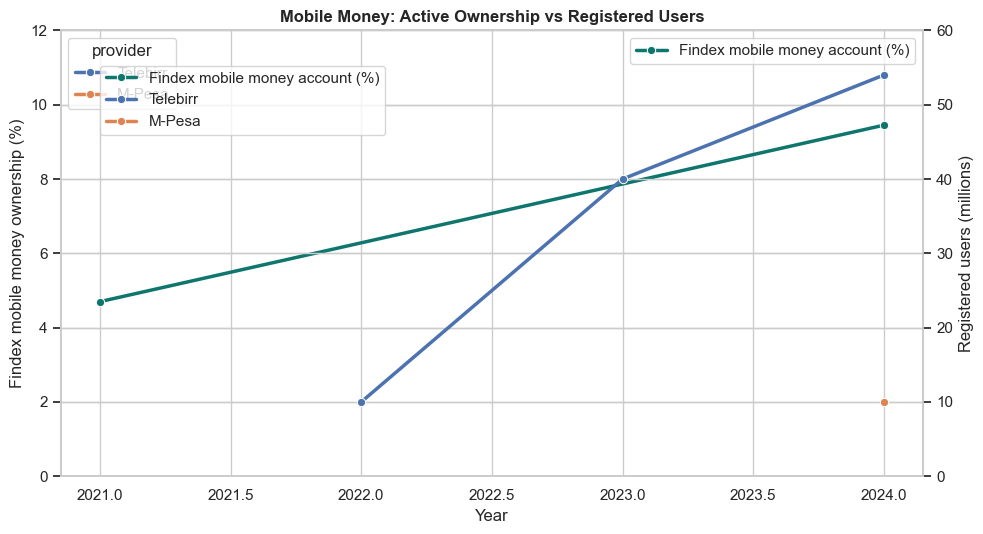

In [4]:
mm = series("ACC_MM_ACCOUNT")
telebirr = series("ACC_TELEBIRR_USERS")
mpesa = series("ACC_MPESA_USERS")

fig, ax1 = plt.subplots()
sns.lineplot(data=mm, x="observation_year", y="value_numeric", marker="o", color="#0F766E", linewidth=2.5, ax=ax1, label="Findex mobile money account (%)")
ax1.set_ylabel("Findex mobile money ownership (%)")
ax1.set_xlabel("Year")
ax1.set_ylim(0, 12)

ax2 = ax1.twinx()
operator = pd.concat([telebirr.assign(provider="Telebirr"), mpesa.assign(provider="M-Pesa")])
sns.lineplot(data=operator, x="observation_year", y="value_numeric", hue="provider", marker="o", linewidth=2.5, ax=ax2)
ax2.set_ylabel("Registered users (millions)")
ax2.set_ylim(0, 60)
ax1.set_title("Mobile Money: Active Ownership vs Registered Users")
fig.legend(loc="upper left", bbox_to_anchor=(0.10, 0.88))
savefig("eda_mobile_money_active_vs_registered.png")
plt.show()

## Insight 3: Access gender inclusion improved, but usage remains unequal.

Female account ownership rose from 36% in 2021 to 44% in 2024 while male ownership moved from 56% to 54%, narrowing the account ownership gap from 20pp to 10pp. However, the 2024 digital payment gap remains 14pp: 42% for men vs 28% for women. Ethiopia's next inclusion challenge is not just account opening; it is active digital usage.

saved: reports\figures\eda_gender_access_usage_gap.png


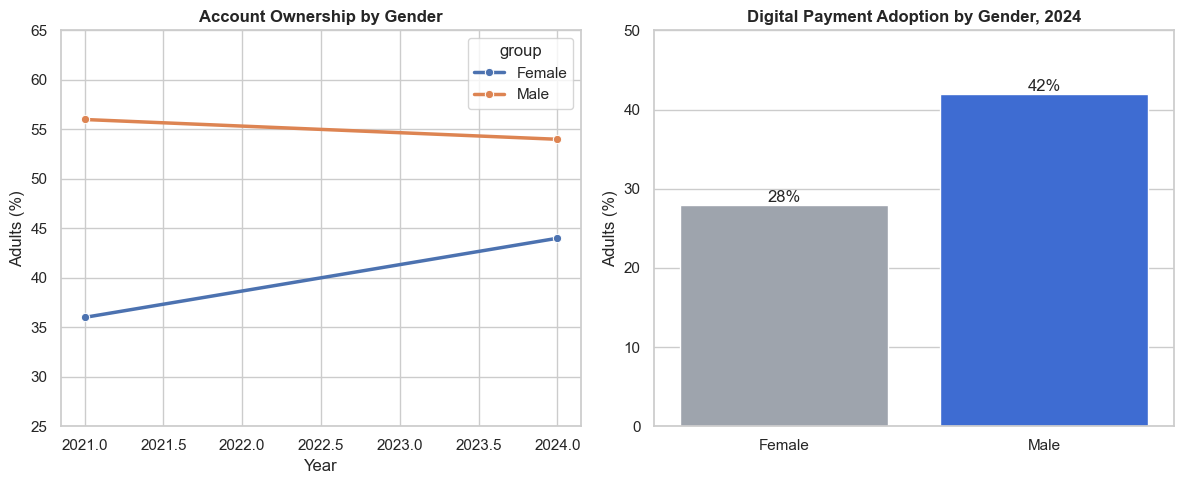

In [5]:
gender_access = pd.concat([
    series("ACC_OWNERSHIP_FEMALE").assign(group="Female", metric="Account ownership"),
    series("ACC_OWNERSHIP_MALE").assign(group="Male", metric="Account ownership"),
])
gender_usage = pd.concat([
    series("USG_DIGITAL_PAYMENT_FEMALE").assign(group="Female", metric="Digital payment adoption"),
    series("USG_DIGITAL_PAYMENT_MALE").assign(group="Male", metric="Digital payment adoption"),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(data=gender_access, x="observation_year", y="value_numeric", hue="group", marker="o", linewidth=2.5, ax=axes[0])
axes[0].set_title("Account Ownership by Gender")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Adults (%)")
axes[0].set_ylim(25, 65)
sns.barplot(data=gender_usage, x="group", y="value_numeric", hue="group", palette=["#9CA3AF", "#2563EB"], ax=axes[1], legend=False)
axes[1].set_title("Digital Payment Adoption by Gender, 2024")
axes[1].set_xlabel("")
axes[1].set_ylabel("Adults (%)")
axes[1].set_ylim(0, 50)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f%%")
savefig("eda_gender_access_usage_gap.png")
plt.show()

## Insight 4: The urban-rural divide is the national access bottleneck.

In 2024, account ownership is 62% in urban areas and 41% in rural areas, a 21pp gap. Because Ethiopia is heavily rural, national progress toward the 70% 2030 target depends on rural conversion through agents, connectivity, trust, and frequent low-value use cases.

saved: reports\figures\eda_rural_gap_and_infrastructure.png


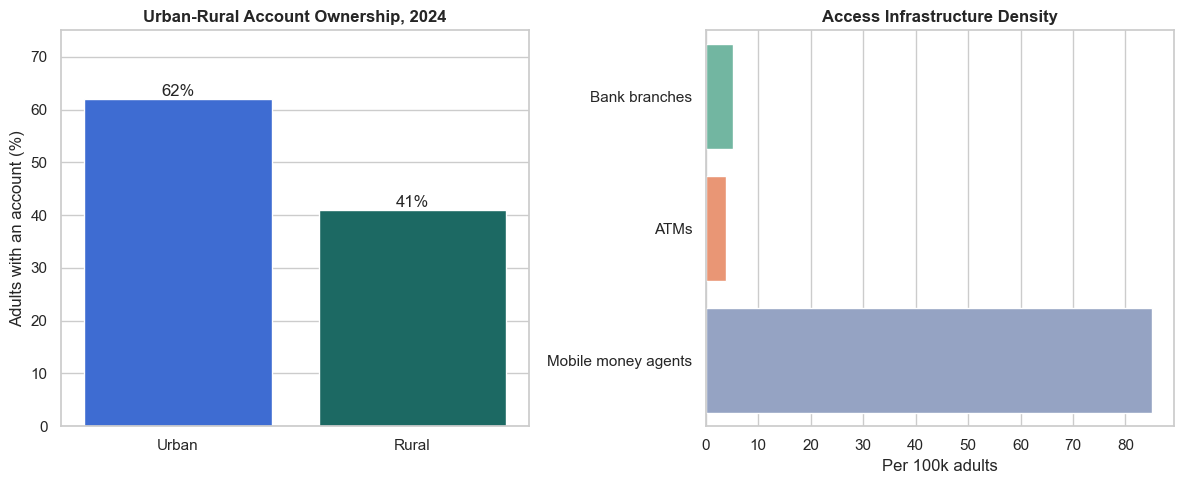

In [6]:
geo = pd.concat([
    series("ACC_OWNERSHIP_URBAN").assign(area="Urban"),
    series("ACC_OWNERSHIP_RURAL").assign(area="Rural"),
])
infra = pd.concat([
    series("INFRA_BANK_BRANCH").assign(channel="Bank branches"),
    series("INFRA_ATM_DENSITY").assign(channel="ATMs"),
    series("INFRA_AGENT_DENSITY").assign(channel="Mobile money agents"),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=geo, x="area", y="value_numeric", hue="area", palette=["#2563EB", "#0F766E"], ax=axes[0], legend=False)
axes[0].set_title("Urban-Rural Account Ownership, 2024")
axes[0].set_xlabel("")
axes[0].set_ylabel("Adults with an account (%)")
axes[0].set_ylim(0, 75)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f%%")
sns.barplot(data=infra, y="channel", x="value_numeric", hue="channel", palette="Set2", ax=axes[1], legend=False)
axes[1].set_title("Access Infrastructure Density")
axes[1].set_xlabel("Per 100k adults")
axes[1].set_ylabel("")
savefig("eda_rural_gap_and_infrastructure.png")
plt.show()

## Insight 5: Ethiopia crossed a behavioral threshold when P2P exceeded ATM withdrawals.

The 2023 P2P/ATM crossover is especially important because it is about transaction behavior, not registration. P2P transfers at ETB 180B exceeded ATM withdrawals at ETB 160B, indicating that digital rails are becoming a real substitute for cash withdrawal in some use cases.

saved: reports\figures\eda_p2p_atm_crossover.png


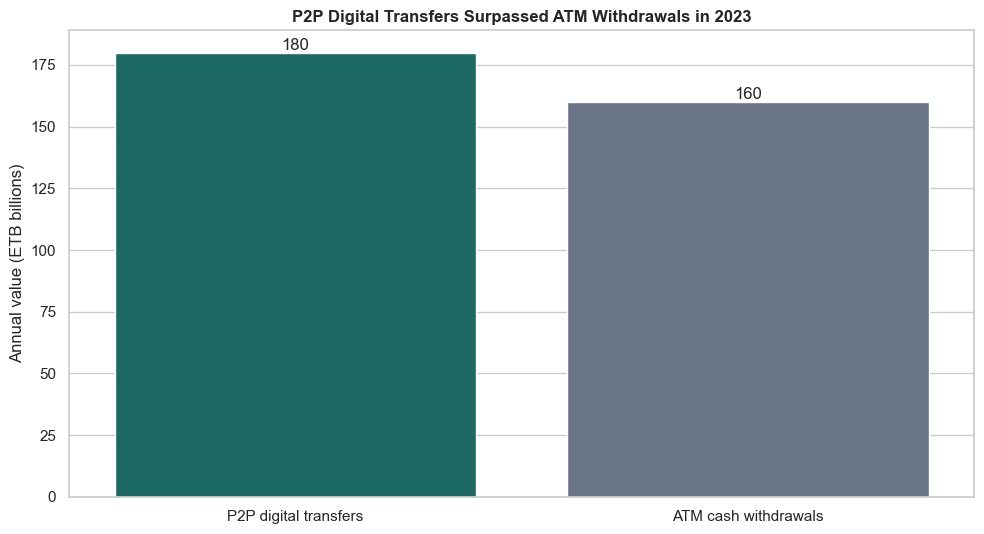

In [7]:
payments = pd.concat([
    series("USG_P2P_TRANSFER").assign(flow="P2P digital transfers"),
    series("USG_ATM_WITHDRAWAL").assign(flow="ATM cash withdrawals"),
])
fig, ax = plt.subplots()
sns.barplot(data=payments, x="flow", y="value_numeric", hue="flow", palette=["#0F766E", "#64748B"], ax=ax, legend=False)
ax.set_title("P2P Digital Transfers Surpassed ATM Withdrawals in 2023")
ax.set_xlabel("")
ax.set_ylabel("Annual value (ETB billions)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
savefig("eda_p2p_atm_crossover.png")
plt.show()

## Insight 6: The 2011-2024 story is event-rich, but event overlays should be read as context, not causality.

The event timeline clusters heavily after 2020: NFIS-II, Telebirr, Fayda, EthSwitch interoperability, Safaricom entry, rural 4G expansion, M-Pesa, and the P2P/ATM crossover. The enriched dataset includes `prior_24m_events` so plots can show policy and market context while keeping causal claims in the event-impact model rather than the descriptive EDA.

saved: reports\figures\eda_event_overlay_timeline.png


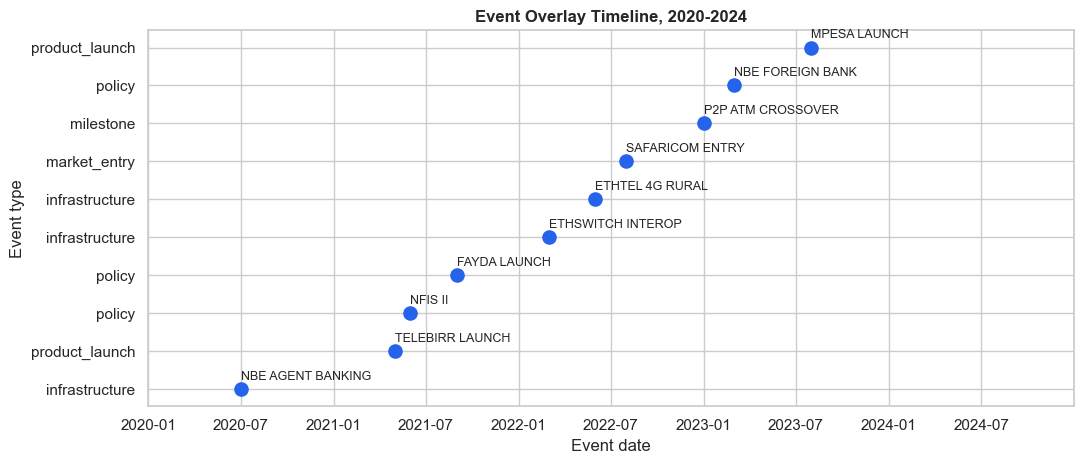

In [8]:
timeline = events.sort_values("observation_date").copy()
timeline["event_date"] = timeline["observation_date"].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(11, 4.8))
ypos = range(len(timeline))
ax.scatter(timeline["observation_date"], ypos, s=90, color="#2563EB")
for y, (_, row) in zip(ypos, timeline.iterrows()):
    ax.text(row["observation_date"], y + 0.16, row["indicator_code"].replace("_", " "), fontsize=9, va="bottom")
ax.set_yticks(list(ypos))
ax.set_yticklabels(timeline["category"].fillna("event"))
ax.set_title("Event Overlay Timeline, 2020-2024")
ax.set_xlabel("Event date")
ax.set_ylabel("Event type")
ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2024-12-31"))
savefig("eda_event_overlay_timeline.png")
plt.show()

## Reproducibility Notes

- Source rows retain `source_name`, `source_url`, `confidence`, `evidence_basis`, and `notes`.
- Derived fields are documented in `data/processed/data_enrichment_log.md`.
- Figures generated by this notebook are saved under `reports/figures`.
- The descriptive EDA covers 2011-2024; forecasts are intentionally left to `task4_forecasting.ipynb`.